# **Implementación del caso de 10 Qubits.**

In [1]:
%load_ext autoreload
%autoreload 2

import modules
from modules.Schnorr_QAOA import SchnorrAlgQAOA


import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram

In [2]:
N10 = 261980999226229

## **Implementación con 8 Qubits**

In [3]:
seed = 51

In [4]:
eightQubit = SchnorrAlgQAOA(N10, 4, 1, seed)

El numero de bits de N = 261980999226229 es m = 48
La dimension del reticulo que vamos a tratar es n = 8
La cota smooth que vamos a tomar: 64


In [5]:
B8, t8 = eightQubit.generate_cvp(10)
print(f'B8 = \n{B8}')
print(f't8 = \n{t8}')

B8 = 
[ 2 0 0 0 0 0 0 0  6931 ]
[ 0 3 0 0 0 0 0 0 10986 ]
[ 0 0 2 0 0 0 0 0 16094 ]
[ 0 0 0 4 0 0 0 0 19459 ]
[ 0 0 0 0 1 0 0 0 23979 ]
[ 0 0 0 0 0 3 0 0 25649 ]
[ 0 0 0 0 0 0 1 0 28332 ]
[ 0 0 0 0 0 0 0 4 29444 ]
t8 = 
(0, 0, 0, 0, 0, 0, 0, 0, 331993)


In [6]:
D8, b8_op, res8_vector, sign_step8, w8, dist8 = eightQubit.babai_algorithm(B8, t8, delta = 0.75)
print(f'D8 = \n{D8}\n')
print(f'b8_op = \n{b8_op}\n')
print(f'res8_vector = \n{res8_vector}\n')
print(f'sign_step8 = \n{sign_step8}\n')
print(f'w8 = \n{w8}\n')
print(f'dist8 = \n{dist8}\n')

D8 = 
[  2  0 -4 -4  3  0 -2  4  1 ]
[  0 -3  4  0 -2  3 -1  4  5 ]
[  6 -3  0  0 -4  0  2  4 -1 ]
[  4  0 -2  0 -2  6  1 -4 -4 ]
[ -4  0  6  4 -1  3 -3  4 -3 ]
[  2 -6  6  0  2 -3 -3  4 -2 ]
[  2 -6 -4  4  1 -3  0  4  4 ]
[ -8 -3  0  0 -3  3  3  0 -2 ]

b8_op = 
[     2      0      2      0      0      3     10      0 331994]

res8_vector = 
[ -2   0  -2   0   0  -3 -10   0  -1]

sign_step8 = 
[ 1 -1 -1 -1  1  1  1 -1]

w8 = 
(-8765, 35541, -13511, -8003, -15327, -12503, 6562, -10148)

dist8 = 
10.862780491200215



In [7]:
qubo8 = eightQubit.define_qubo(D8, res8_vector, sign_step8)
print(qubo8.prettyprint())

Hc8, offset8 = eightQubit.define_hamiltonian(qubo8)
print(f'Offset = {offset8}')
print(f'Hamiltonian = {Hc8}')


Problem name: quboProblem

Minimize
  66*z_0^2 - 2*z_0*z_1 - 22*z_0*z_2 + 24*z_0*z_3 - 64*z_0*z_4 + 12*z_0*z_5
  + 54*z_0*z_6 + 66*z_0*z_7 + 80*z_1^2 + 52*z_1*z_2 - 46*z_1*z_3 - 78*z_1*z_4
  - 76*z_1*z_5 - 54*z_1*z_6 + 22*z_1*z_7 + 82*z_2^2 + 44*z_2*z_3 + 14*z_2*z_4
  - 68*z_2*z_5 - 76*z_2*z_6 - 38*z_2*z_7 + 93*z_3^2 + 30*z_3*z_4 + 74*z_3*z_5
  + 72*z_3*z_6 + 6*z_3*z_7 + 112*z_4^2 + 96*z_4*z_5 - 44*z_4*z_6 - 82*z_4*z_7
  + 118*z_5^2 + 70*z_5*z_6 + 36*z_5*z_7 + 114*z_6^2 + 36*z_6*z_7 + 104*z_7^2
  - 46*z_0 - 24*z_1 - 62*z_2 - 56*z_3 - 40*z_4 - 50*z_5 - 18*z_6 - 42*z_7 + 118

Subject to
  No constraints

  Binary variables (8)
    z_0 z_1 z_2 z_3 z_4 z_5 z_6 z_7

Offset = 348.0
Hamiltonian = SparsePauliOp(['IIIIIIIZ', 'IIIIIZII', 'IIIIZIII', 'IIIZIIII', 'IIZIIIII', 'IZIIIIII', 'ZIIIIIII', 'IIIIIIZI', 'IIIIIIZZ', 'IIIIIZIZ', 'IIIIZIIZ', 'IIIZIIIZ', 'IIZIIIIZ', 'IZIIIIIZ', 'ZIIIIIIZ', 'IIIIIZZI', 'IIIIZIZI', 'IIIZIIZI', 'IIZIIIZI', 'IZIIIIZI', 'ZIIIIIZI', 'IIIIZZII', 'IIIZIZII', 'IIZIIZII'

In [8]:
circuit8 = eightQubit.construct_circuit(Hc8, reps = 1)
print(circuit8.decompose())

     ┌───┐»
q_0: ┤ H ├»
     ├───┤»
q_1: ┤ H ├»
     ├───┤»
q_2: ┤ H ├»
     ├───┤»
q_3: ┤ H ├»
     ├───┤»
q_4: ┤ H ├»
     ├───┤»
q_5: ┤ H ├»
     ├───┤»
q_6: ┤ H ├»
     ├───┤»
q_7: ┤ H ├»
     └───┘»
«     ┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐»
«q_0: ┤0                                                                                                                                                                                                                                                                                                                                                                             

In [9]:
x0 = np.asarray([0.0]*circuit8.num_parameters)
optParameters8 = eightQubit.qaoa_algorithm(circuit8, Hc8, x0)

In [10]:
for param in optParameters8.items():
    print(f'{param[0].name} = {param[1]}')

β[0] = -0.4799726604811829
γ[0] = 0.008447652215877989


In [11]:
results8 = eightQubit.sample_from_parameters(circuit8, optParameters8, shots = 10_000)
print(len(results8))
for bitstring, count in results8.items():
    print(f"Bistring: {bitstring} -> Counts: {count}")

/home/zheng/tfg/TFG_GII/.venv/lib/python3.12/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/zheng/tfg/TFG_GII/.venv/lib/python3.12/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/home/zheng/tfg/TFG_GII/.venv/lib/python3.12/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


218
Bistring: 00000100 -> Counts: 378
Bistring: 00010011 -> Counts: 347
Bistring: 00100110 -> Counts: 302
Bistring: 00000000 -> Counts: 286
Bistring: 00000010 -> Counts: 280
Bistring: 00010010 -> Counts: 255
Bistring: 00000101 -> Counts: 250
Bistring: 00010111 -> Counts: 234
Bistring: 10010100 -> Counts: 228
Bistring: 01010110 -> Counts: 221
Bistring: 10000100 -> Counts: 216
Bistring: 00000110 -> Counts: 211
Bistring: 00100100 -> Counts: 207
Bistring: 10010110 -> Counts: 204
Bistring: 00001010 -> Counts: 203
Bistring: 10010010 -> Counts: 199
Bistring: 00100010 -> Counts: 191
Bistring: 01000100 -> Counts: 185
Bistring: 01010111 -> Counts: 177
Bistring: 00100111 -> Counts: 170
Bistring: 11010110 -> Counts: 169
Bistring: 01010010 -> Counts: 166
Bistring: 00000001 -> Counts: 165
Bistring: 00010101 -> Counts: 164
Bistring: 00010110 -> Counts: 162
Bistring: 01000110 -> Counts: 139
Bistring: 00011010 -> Counts: 137
Bistring: 00001000 -> Counts: 134
Bistring: 00011011 -> Counts: 130
Bistring: 

In [12]:
nD8 = eightQubit.integer_to_matrix(D8)
vnew8 = eightQubit.bitstring2latticeVectors(nD8, results8.keys(), sign_step8, b8_op)
for vect8 in vnew8:
    print(vect8)

[     4     -6      8      0      2      0      7      4 331992]
[     8     -3      0      4      6     -9      6      8 332004]
[     0     -9      4      4      7     -3      5      4 331997]
[     2      0      2      0      0      3     10      0 331994]
[     4     -6     -2      4      1      0     10      4 331998]
[     0     -6      0      4      3     -6      9      8 332002]
[    12     -3      8      0      5     -3      4      4 331994]
[    10     -9      6      4      8    -12      3     12 332002]
[     2     -6      6     -4      7     -6      4     12 331997]
[     2     -9      2      4      7    -12      7      8 331995]
[     6     -6      4     -4      5      0      5      8 331993]
[     6    -12      4      4      3     -3      7      8 331996]
[    -2     -3      8      0      6      0      5      0 331993]
[     4    -12      2      0      8     -9      4     16 332001]
[     0     -6      4      8      0      3      7      8 331995]
[     2     -6     -4    

In [13]:
distances8 = eightQubit.get_distances(vnew8, t8)
for dist8 in distances8:
    print(dist8)

13.638181696985855
20.663978319771825
15.0996688705415
10.862780491200215
14.628738838327793
17.97220075561143
16.852299546352718
25.98076211353316
18.788294228055936
20.37154878746336
14.7648230602334
18.76166303929372
11.74734012447073
25.39685019840059
15.556349186104045
20.518284528683193
12.569805089976535
12.884098726725126
24.020824298928627
18.0
22.869193252058544
16.703293088490067
13.416407864998739
20.024984394500787
23.130067012440755
16.673332000533065
19.519221295943137
13.784048752090222
20.074859899884732
22.869193252058544
17.663521732655695
14.933184523068078
14.071247279470288
14.352700094407323
14.106735979665885
22.045407685048602
16.881943016134134
29.171904291629644
20.37154878746336
23.600847442411894
17.233687939614086
15.198684153570664
12.449899597988733
12.165525060596439
21.817424229271428
14.7648230602334
11.74734012447073
17.08800749063506
24.310491562286437
18.81488772222678
20.12461179749811
16.06237840420901
23.302360395462088
18.894443627691185
14.696

In [14]:
nB8 = eightQubit.integer_to_matrix(B8)
uv_pairs8 = eightQubit.vectors2uv_pairs(nB8, vnew8)
print(uv_pairs8)

[[2358421523067500 9]
 [1728919862986450288 6591]
 [91999412213868775 351]
 [262079207058370 1]
 [11797596305427548 45]
 [398862851561440189 1521]
 [10222866833960000 39]
 [202258638561258356000 771147]
 [2790906538588792250 10647]
 [202067508986541377410 771147]
 [16509929936845400 63]
 [276029655059820200 1053]
 [1572102054235625 6]
 [46663957325204606420 177957]
 [2359006255676525 9]
 [9972162781153990054 38025]
 [7864168981413437 30]
 [10213206469368100 39]
 [875886356885280922720 3341637]
 [398782715755454800 1521]
 [1010397475978377635852 3855735]
 [43182151876941182567 164775]
 [262157171406240 1]
 [1728115503770150000 6591]
 [46661189484009311750 177957]
 [1195353685174842424 4563]
 [122700348004532375 468]
 [5764488970638125 22]
 [132964920166116500 507]
 [12097526083001612000 46137]
 [51138125568977216 195]
 [44316127725216600 169]
 [3407234413495000 13]
 [398405875629322253 1521]
 [23856848758741603 91]
 [1196484334246678400 4563]
 [12086094210267675070 46137]
 [202270636107

In [15]:
sr_pairs8 = eightQubit.uv_pairs2sr_pairs(uv_pairs8)
print(sr_pairs8)

[]


In [16]:
probs8 = eightQubit.get_probs(results8.values(), shots = 10_000)

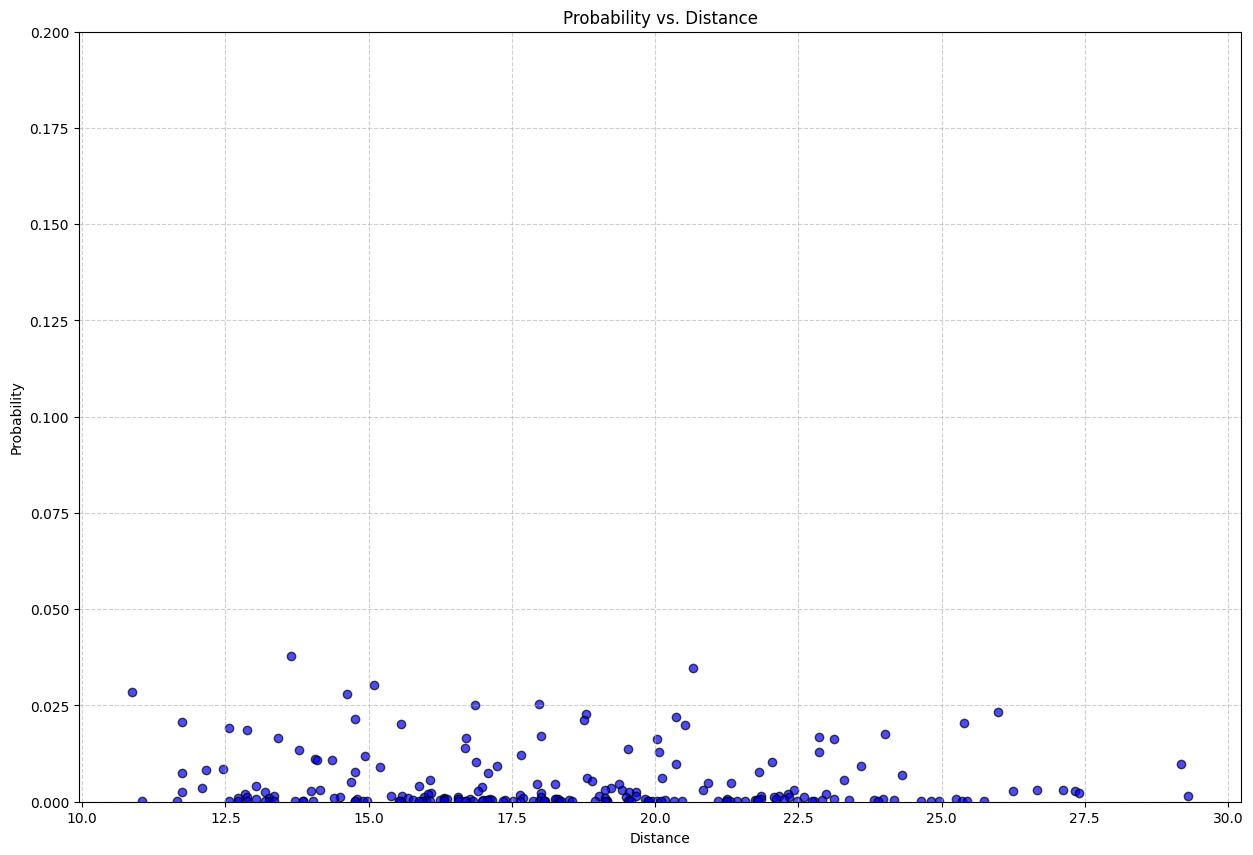

In [17]:
plt.figure(figsize=(15, 10))

# Creating the scatter plot
plt.scatter(distances8, probs8, color='blue', edgecolors='black', alpha=0.7)

# Adding labels and title
plt.xlabel('Distance')
plt.ylabel('Probability')
plt.title('Probability vs. Distance')

# Setting y-axis limit since you mentioned probs are <= 0.2
plt.ylim(0, 0.20) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## **Implementación con 10 Qubits**

In [18]:
seed = 42

In [19]:
tenQubit = SchnorrAlgQAOA(N10, 4, 1, seed)

El numero de bits de N = 261980999226229 es m = 48
La dimension del reticulo que vamos a tratar es n = 8
La cota smooth que vamos a tomar: 64


In [20]:
tenQubit.set_n(10)
tenQubit.set_smoothbound(200)

print(f'La dimension del retículo que vamos a tratar es n = {tenQubit.get_n()}')
print(f'La cota smooth que vamos a tomar es Smooth Bound = {tenQubit.get_smoothbound()}')

La dimension del retículo que vamos a tratar es n = 10
La cota smooth que vamos a tomar es Smooth Bound = 200


In [21]:
B10, t10 = tenQubit.generate_cvp(10)
print(f'B10 = \n{B10}')
print(f't10 = \n{t10}')

B10 = 
[ 5 0 0 0 0 0 0 0 0 0  6931 ]
[ 0 1 0 0 0 0 0 0 0 0 10986 ]
[ 0 0 3 0 0 0 0 0 0 0 16094 ]
[ 0 0 0 1 0 0 0 0 0 0 19459 ]
[ 0 0 0 0 4 0 0 0 0 0 23979 ]
[ 0 0 0 0 0 2 0 0 0 0 25649 ]
[ 0 0 0 0 0 0 5 0 0 0 28332 ]
[ 0 0 0 0 0 0 0 3 0 0 29444 ]
[ 0 0 0 0 0 0 0 0 2 0 31355 ]
[ 0 0 0 0 0 0 0 0 0 4 33673 ]
t10 = 
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 331993)


In [22]:
D10, b10_op, res10_vector, sign_step10, w10, dist10 = tenQubit.babai_algorithm(B10, t10, delta = 0.75)
print(f'D10 = \n{D10}\n')
print(f'b10_op = \n{b10_op}\n')
print(f'res10_vector = \n{res10_vector}\n')
print(f'sign_step10 = \n{sign_step10}\n')
print(f'w10 = \n{w10}\n')
print(f'dist10 = \n{dist10}\n')

D10 = 
[  0  1  3 -1  0  2  0  3 -4  0  4 ]
[  5  3 -3  2  0  0  0  0 -4  0  3 ]
[  0  4 -3  1 -4 -2  0  0 -2  4 -1 ]
[  0  4 -3 -1  0  4 -5  0 -2  0  2 ]
[  0  1 -3 -3  0 -2  5  3  2  0 -3 ]
[  0 -1 -6  0  0 -4  0  3  2  4  0 ]
[ -5 -2  3  4  0  0  0  0 -2 -4 -1 ]
[  0  5  0  3  0 -4 -5  0  0 -4  4 ]
[ -5  4  0 -2  0  0  0 -3  2  0  6 ]
[ -5  2  0  1  4  0  0 -3 -4  4 -2 ]

b10_op = 
[     0      1      0      6      0      4      0      6      6      0
 331991]

res10_vector = 
[ 0 -1  0 -6  0 -4  0 -6 -6  0  2]

sign_step10 = 
[ 1  1  1 -1 -1 -1 -1  1  1  1]

w10 = 
(15714, 20489, -11636, -10577, -17862, 19313, 3326, -7285, 28799, -11636)

dist10 = 
11.357816691600547



In [23]:
qubo10 = tenQubit.define_qubo(D10, res10_vector, sign_step10)
print(qubo10.prettyprint())
Hc10, offset10 = tenQubit.define_hamiltonian(qubo10)
print(f'Offset = {offset10}')
print(f'Hamiltonian = \n{Hc10}')

Problem name: quboProblem

Minimize
  56*z_0^2 + 40*z_0*z_1 - 12*z_0*z_2 - 40*z_0*z_3 + 40*z_0*z_4 + 52*z_0*z_5
  - 14*z_0*z_6 + 20*z_0*z_7 + 26*z_0*z_8 + 72*z_1^2 + 56*z_1*z_2 - 66*z_1*z_3
  + 22*z_1*z_4 - 14*z_1*z_5 + 54*z_1*z_6 + 66*z_1*z_7 - 14*z_1*z_8 - 14*z_1*z_9
  + 67*z_2^2 - 36*z_2*z_3 - 26*z_2*z_4 - 68*z_2*z_5 + 48*z_2*z_6 + 22*z_2*z_7
  + 8*z_2*z_8 + 38*z_2*z_9 + 75*z_3^2 - 54*z_3*z_4 - 12*z_3*z_5 - 38*z_3*z_6
  - 68*z_3*z_7 - 52*z_3*z_8 - 22*z_3*z_9 + 70*z_4^2 + 76*z_4*z_5 - 48*z_4*z_6
  + 66*z_4*z_7 + 26*z_4*z_8 + 24*z_4*z_9 + 82*z_5^2 - 72*z_5*z_6 + 10*z_5*z_7
  + 18*z_5*z_8 + 6*z_5*z_9 + 75*z_6^2 - 28*z_6*z_7 + 2*z_6*z_8 - 38*z_6*z_9
  + 107*z_7^2 + 76*z_7*z_8 - 22*z_7*z_9 + 94*z_8^2 + 40*z_8*z_9 + 91*z_9^2
  - 22*z_0 - 30*z_1 - 16*z_2 + 4*z_3 - 22*z_4 - 26*z_5 - 24*z_6 - 2*z_7 - 52*z_8
  - 60*z_9 + 129

Subject to
  No constraints

  Binary variables (10)
    z_0 z_1 z_2 z_3 z_4 z_5 z_6 z_7 z_8 z_9

Offset = 418.0
Hamiltonian = 
SparsePauliOp(['IIIIIIIIIZ', 'IIIIIIIIZI'

In [24]:
circuit10 = tenQubit.construct_circuit(Hc10, reps= 1)
print(circuit10.decompose(reps = 2))

     ┌────────────┐ ┌────────────────┐                              »
q_0: ┤ U(π/2,0,π) ├─┤ Rz((-90)*γ[0]) ├─■─────────────■──────────────»
     ├────────────┤┌┴────────────────┤ │ZZ(20*γ[0])  │              »
q_1: ┤ U(π/2,0,π) ├┤ Rz((-107)*γ[0]) ├─■─────────────┼──────────────»
     ├────────────┤└┬────────────────┤               │ZZ((-6)*γ[0]) »
q_2: ┤ U(π/2,0,π) ├─┤ Rz((-66)*γ[0]) ├───────────────■──────────────»
     ├────────────┤ └┬──────────────┬┘                              »
q_3: ┤ U(π/2,0,π) ├──┤ Rz(115*γ[0]) ├───────────────────────────────»
     ├────────────┤┌─┴──────────────┴┐                              »
q_4: ┤ U(π/2,0,π) ├┤ Rz((-111)*γ[0]) ├──────────────────────────────»
     ├────────────┤└┬────────────────┤                              »
q_5: ┤ U(π/2,0,π) ├─┤ Rz((-54)*γ[0]) ├──────────────────────────────»
     ├────────────┤ └┬─────────────┬─┘                              »
q_6: ┤ U(π/2,0,π) ├──┤ Rz(16*γ[0]) ├────────────────────────────────»
     ├────────────┤┌

In [25]:
x0 = np.asarray([0.0]*circuit10.num_parameters)
optParameters10 = tenQubit.qaoa_algorithm(circuit10, Hc10, x0)

In [26]:
for param in optParameters10.items():
    print(f'{param[0].name} = {param[1]}')

β[0] = 0.5090447457358702
γ[0] = -0.008621815614845957


In [27]:
results10 = tenQubit.sample_from_parameters(circuit10, optParameters10, shots = 10_000)
print(len(results10))
for bitstring, count in results10.items():
    print(f"Bistring: {bitstring} -> Counts: {count}")

594
Bistring: 0000000000 -> Counts: 223
Bistring: 0001001000 -> Counts: 223
Bistring: 1001001000 -> Counts: 213
Bistring: 1001101000 -> Counts: 204
Bistring: 0000001000 -> Counts: 203
Bistring: 0001011000 -> Counts: 176
Bistring: 0001101100 -> Counts: 173
Bistring: 0001101000 -> Counts: 171
Bistring: 1001001001 -> Counts: 167
Bistring: 1001011000 -> Counts: 154
Bistring: 0000101100 -> Counts: 133
Bistring: 0000001100 -> Counts: 133
Bistring: 1000001000 -> Counts: 129
Bistring: 0000001010 -> Counts: 128
Bistring: 0001001001 -> Counts: 126
Bistring: 1000001010 -> Counts: 125
Bistring: 0100001000 -> Counts: 117
Bistring: 1011001000 -> Counts: 108
Bistring: 0000001001 -> Counts: 100
Bistring: 1000000000 -> Counts: 100
Bistring: 0101001000 -> Counts: 98
Bistring: 0001000000 -> Counts: 98
Bistring: 1001000000 -> Counts: 97
Bistring: 1001101010 -> Counts: 97
Bistring: 1011101000 -> Counts: 95
Bistring: 0000011000 -> Counts: 94
Bistring: 0011001000 -> Counts: 93
Bistring: 0100001010 -> Counts:

In [28]:
nD10 = tenQubit.integer_to_matrix(D10)
vnew10 = tenQubit.bitstring2latticeVectors(nD10, results10.keys(), sign_step10, b10_op)
for vect10 in vnew10:
    print(vect10)

[     0      1      0      6      0      4      0      6      6      0
 331991]
[     5     -1      0      3      0      0      5      6     10      4
 331990]
[     5      0      3      2      0      2      5      9      6      4
 331994]
[     5     -1      6      5      0      4      0      6      4      4
 331997]
[     5      3     -3      2      0      4      0      6      8      4
 331992]
[     5      0      6      3      0      4      5      3      8      0
 331990]
[     5      3      3      9      0     -2     -5      3      8      0
 331997]
[     5     -2      3      6      0      2      0      3      8      4
 331993]
[     0      2      3      3      4      2      5      6      2      8
 331992]
[     5      1      9      2      0      6      5      6      4      0
 331994]
[     5      7      0      8      0      2    -10      3      6      0
 331999]
[     5      8     -3      5      0      0     -5      6      8      0
 331996]
[     5      4      0      1      0     

In [29]:
distances10 = tenQubit.get_distances(vnew10, t10)
for dist10 in distances10:
    print(dist10)

11.357816691600547
14.866068747318506
14.177446878757825
13.674794331177344
13.416407864998739
13.892443989449804
15.556349186104045
12.922847983320086
13.114877048604
15.0
17.97220075561143
16.0312195418814
14.142135623730951
14.966629547095765
13.856406460551018
16.431676725154983
16.61324772583615
15.874507866387544
13.152946437965905
12.767145334803704
15.84297951775486
14.422205101855956
14.212670403551895
15.198684153570664
14.560219778561036
12.806248474865697
16.852299546352718
17.4928556845359
15.84297951775486
14.560219778561036
14.212670403551895
16.792855623746664
17.320508075688775
14.798648586948742
14.798648586948742
14.2828568570857
15.165750888103101
15.0996688705415
15.297058540778355
14.66287829861518
18.65475810617763
16.15549442140351
13.416407864998739
15.362291495737216
16.703293088490067
16.46207763315433
13.892443989449804
13.038404810405298
21.656407827707714
15.811388300841896
13.601470508735444
17.46424919657298
15.874507866387544
12.649110640673518
14.42220

In [30]:
nB10 = tenQubit.integer_to_matrix(B10)
uv_pairs10 = tenQubit.vectors2uv_pairs(nB10, vnew10)
for pair10 in uv_pairs10:
    print(pair10)

[261991323844341 1]
[785809757098954 3]
[262078058335730 1]
[786516396634150 3]
[1310065736807646 5]
[261977923439050 1]
[57931005868178310 221]
[2358275479138670 9]
[262012871275155 1]
[262119418401750 1]
[75778073514523926 289]
[22279671311401854 85]
[262154661348762 1]
[1310769316687779 5]
[261871433827773 1]
[1836068173280991 7]
[6552805178814804 25]
[2882508035594922 11]
[1309739882231781 5]
[262132826044635 1]
[1310178082724532 5]
[7071698751104155 27]
[2358506064707975 9]
[262312933571325 1]
[2883542722375770 11]
[262054497183570 1]
[187261881680842038 715]
[6556324408234146 25]
[129242486897948970 493]
[7600277737807650 29]
[21222711489550025 81]
[4458638042784450 17]
[129251100049139250 493]
[262218809172645 1]
[262129675185924 1]
[2881986154104582 11]
[44284284952292574 169]
[22274129656016469 85]
[129211330479893361 493]
[57916596603958785 221]
[2197381093096279545 8381]
[261981005921397 1]
[4455822364931574 17]
[7078057977206125 27]
[72044852542903422 275]
[262177142667804 

In [31]:
sr_pairs10 = tenQubit.uv_pairs2sr_pairs(uv_pairs10)
print(sr_pairs10)

[]


In [32]:
probs10 = tenQubit.get_probs(results10.values(), shots = 10_000)

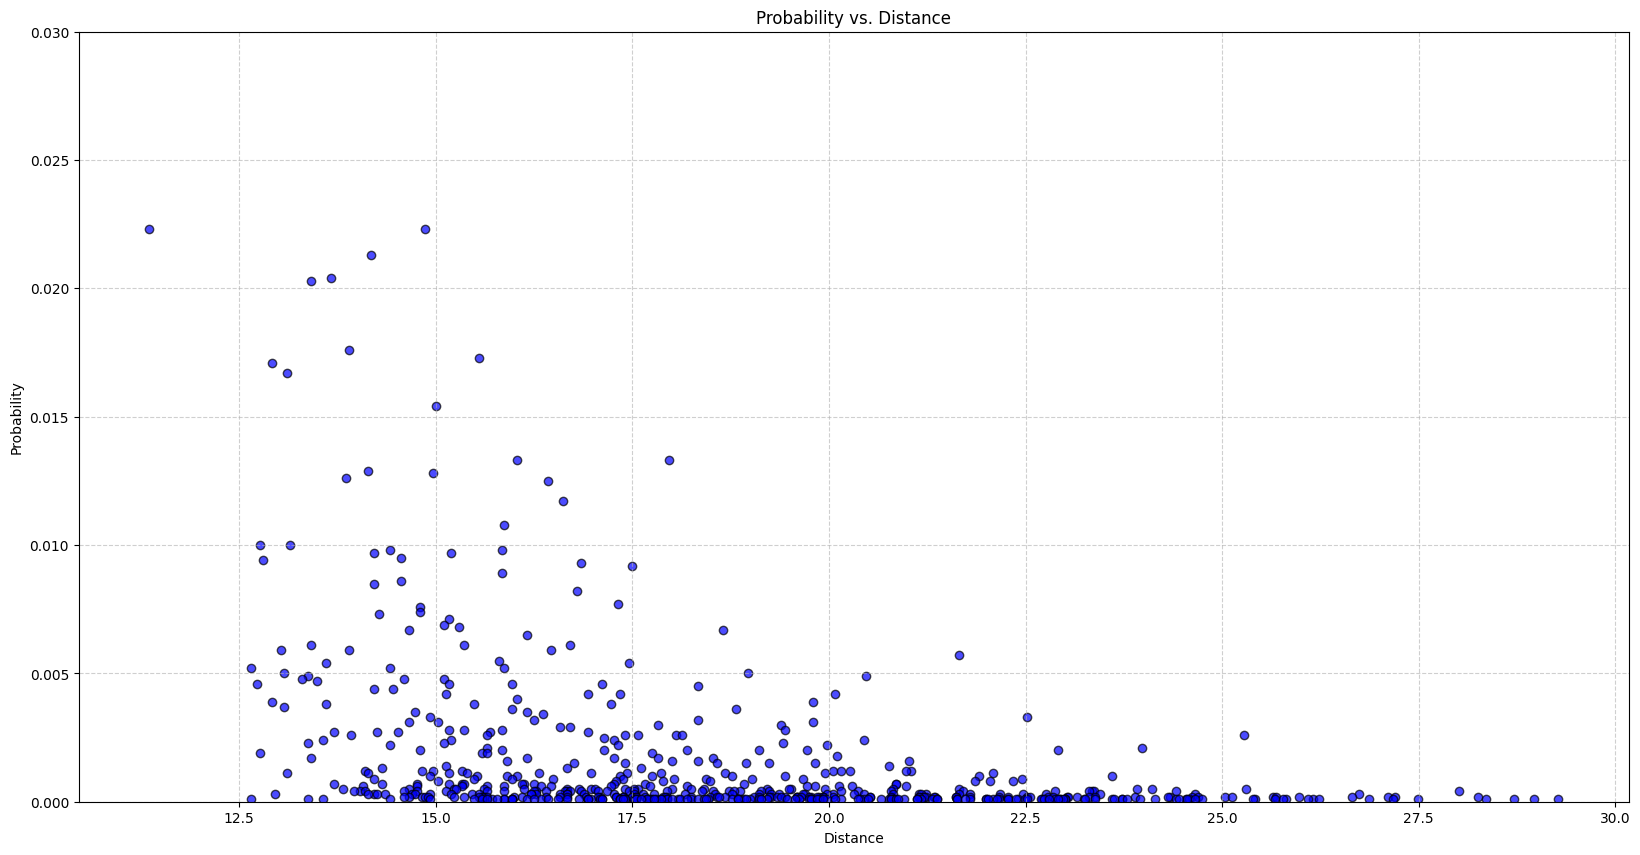

In [33]:
plt.figure(figsize=(20, 10))

# Creating the scatter plot
plt.scatter(distances10, probs10, color='blue', edgecolors='black', alpha=0.7)

# Adding labels and title
plt.xlabel('Distance')
plt.ylabel('Probability')
plt.title('Probability vs. Distance')

# Setting y-axis limit since you mentioned probs are <= 0.2
plt.ylim(0, 0.03) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()